**DL Models**

0) Load panels + clean

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

PANEL_DIR = Path(r"D:\Thesis\Old\Codes\New\panel_data")

panel_return = pd.read_parquet(PANEL_DIR / "panel_return.parquet").sort_index()
panel_risk   = pd.read_parquet(PANEL_DIR / "panel_risk.parquet").sort_index()

def clean_return_panel(panel: pd.DataFrame) -> pd.DataFrame:
    panel = panel.copy()
    panel = panel.dropna(subset=["y"])
    feat_cols = [c for c in panel.columns if c != "y"]
    panel[feat_cols] = (
        panel[feat_cols]
        .groupby(level="Ticker", group_keys=False)
        .apply(lambda df: df.ffill())
    )
    panel = panel.dropna()
    return panel

def clean_risk_panel(panel: pd.DataFrame) -> pd.DataFrame:
    return panel.dropna().copy()

panel_return_clean = clean_return_panel(panel_return)
panel_risk_clean   = clean_risk_panel(panel_risk)

print("panel_return_clean:", panel_return_clean.shape)
print("panel_risk_clean  :", panel_risk_clean.shape)


panel_return_clean: (220653, 15)
panel_risk_clean  : (236800, 6)


1) Time split by Date (no leakage)

In [2]:
def time_split_panel(panel: pd.DataFrame, train_ratio=0.7):
    dates = panel.index.get_level_values("Date").unique().sort_values()
    split_date = dates[int(len(dates) * train_ratio)]

    train_mask = panel.index.get_level_values("Date") <= split_date
    test_mask  = panel.index.get_level_values("Date") > split_date

    train = panel.loc[train_mask].copy()
    test  = panel.loc[test_mask].copy()

    return train, test, split_date


2) MLP tensors (tabular)

In [3]:
def make_tabular_tensors(train: pd.DataFrame, test: pd.DataFrame):
    X_train = train.drop(columns=["y"]).astype(float)
    y_train = train["y"].astype(float).values

    X_test = test.drop(columns=["y"]).astype(float)
    y_test = test["y"].astype(float).values

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    return X_train_scaled, y_train, X_test_scaled, y_test, scaler


3) Sequence tensors (LSTM / GRU / CNN / Transformer)

In [4]:
def make_sequence_tensors(train: pd.DataFrame, test: pd.DataFrame, lookback=20):
    feature_cols = [c for c in train.columns if c != "y"]

    def build_sequences(panel):
        X_list, y_list = [], []

        for ticker, df in panel.groupby(level="Ticker"):
            df = df.droplevel("Ticker").sort_index()

            Xv = df[feature_cols].values.astype(float)
            yv = df["y"].values.astype(float)

            if len(df) <= lookback:
                continue

            # sequence ends at i (inclusive), label is y[i]
            for i in range(lookback, len(df)):
                X_list.append(Xv[i-lookback:i])
                y_list.append(yv[i])

        return np.array(X_list), np.array(y_list)

    X_train_seq, y_train_seq = build_sequences(train)
    X_test_seq,  y_test_seq  = build_sequences(test)

    # --- scale using train only (flatten -> fit -> reshape) ---
    n_feat = X_train_seq.shape[-1]

    scaler = StandardScaler()
    X_train_flat = X_train_seq.reshape(-1, n_feat)
    X_test_flat  = X_test_seq.reshape(-1, n_feat)

    X_train_flat = scaler.fit_transform(X_train_flat)
    X_test_flat  = scaler.transform(X_test_flat)

    X_train_seq = X_train_flat.reshape(-1, lookback, n_feat)
    X_test_seq  = X_test_flat.reshape(-1, lookback, n_feat)

    return X_train_seq, y_train_seq, X_test_seq, y_test_seq, scaler


4) Build tensors for BOTH tasks (Return & Risk)

Return Tensors

In [5]:
train_ret, test_ret, split_ret = time_split_panel(panel_return_clean, train_ratio=0.7)
print("RETURN split_date:", split_ret)

# Tabular (MLP)
Xtr_tab_ret, ytr_ret, Xte_tab_ret, yte_ret, scaler_tab_ret = make_tabular_tensors(train_ret, test_ret)
print("MLP return X_train:", Xtr_tab_ret.shape, "y_train:", ytr_ret.shape)

# Sequence (LSTM/GRU/CNN/Transformer)
Xtr_seq_ret, ytr_seq_ret, Xte_seq_ret, yte_seq_ret, scaler_seq_ret = make_sequence_tensors(train_ret, test_ret, lookback=20)
print("SEQ return X_train:", Xtr_seq_ret.shape, "y_train:", ytr_seq_ret.shape)


RETURN split_date: 2022-09-22 00:00:00
MLP return X_train: (153831, 14) y_train: (153831,)
SEQ return X_train: (151851, 20, 14) y_train: (151851,)


Risk Tensors

In [6]:
train_risk, test_risk, split_risk = time_split_panel(panel_risk_clean, train_ratio=0.7)
print("RISK split_date:", split_risk)

# Tabular (MLP)
Xtr_tab_risk, ytr_risk, Xte_tab_risk, yte_risk, scaler_tab_risk = make_tabular_tensors(train_risk, test_risk)
print("MLP risk X_train:", Xtr_tab_risk.shape, "y_train:", ytr_risk.shape)

# Sequence (LSTM etc.)
Xtr_seq_risk, ytr_seq_risk, Xte_seq_risk, yte_seq_risk, scaler_seq_risk = make_sequence_tensors(train_risk, test_risk, lookback=20)
print("SEQ risk X_train:", Xtr_seq_risk.shape, "y_train:", ytr_seq_risk.shape)


RISK split_date: 2022-07-29 00:00:00
MLP risk X_train: (165800, 5) y_train: (165800,)
SEQ risk X_train: (163800, 20, 5) y_train: (163800,)


**1. MLP**

MLP model builder + trainer

In [7]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import mean_squared_error

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def build_mlp(input_dim, hidden=(64, 32), dropout=0.2, lr=1e-3):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    for h in hidden:
        model.add(layers.Dense(h, activation="relu"))
        model.add(layers.Dropout(dropout))

    model.add(layers.Dense(1))  # regression output

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="mse"
    )
    return model

def train_eval_mlp(X_train, y_train, X_test, y_test,
                   hidden=(64, 32), dropout=0.2, lr=1e-3,
                   epochs=50, batch_size=1024, patience=5, verbose=1):

    tf.random.set_seed(42)
    np.random.seed(42)

    model = build_mlp(
        input_dim=X_train.shape[1],
        hidden=hidden,
        dropout=dropout,
        lr=lr
    )

    es = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True
    )

    hist = model.fit(
        X_train, y_train,
        validation_split=0.1,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[es],
        verbose=verbose
    )

    pred = model.predict(X_test, verbose=0).ravel()
    test_rmse = rmse(y_test, pred)

    return model, hist, test_rmse


Train + evaluate MLP on RETURN

In [8]:
mlp_ret, hist_ret, rmse_mlp_ret = train_eval_mlp(
    Xtr_tab_ret, ytr_ret,
    Xte_tab_ret, yte_ret,
    hidden=(64, 32),
    dropout=0.2,
    lr=1e-3,
    epochs=50,
    batch_size=1024,
    patience=5,
    verbose=1
)

print("\n✅ MLP RETURN Holdout RMSE:", rmse_mlp_ret)


Epoch 1/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.1418 - val_loss: 0.0153
Epoch 2/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0189 - val_loss: 0.0120
Epoch 3/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0112 - val_loss: 0.0113
Epoch 4/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0095 - val_loss: 0.0111
Epoch 5/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0088 - val_loss: 0.0110
Epoch 6/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0086 - val_loss: 0.0110
Epoch 7/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0084 - val_loss: 0.0110
Epoch 8/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0083 - val_loss: 0.0110
Epoch 9/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0082 - val_loss: 0.0110
Epoch 10/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0082 - val_loss: 0.0110
Epoch 11/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0081 - val_loss: 0.0110
Epoch 12/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

Train + evaluate MLP on RISK/CVaR

In [9]:
mlp_risk, hist_risk, rmse_mlp_risk = train_eval_mlp(
    Xtr_tab_risk, ytr_risk,
    Xte_tab_risk, yte_risk,
    hidden=(64, 32),
    dropout=0.2,
    lr=1e-3,
    epochs=50,
    batch_size=1024,
    patience=5,
    verbose=1
)

print("\n✅ MLP RISK(CVaR) Holdout RMSE:", rmse_mlp_risk)


Epoch 1/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0278 - val_loss: 5.5629e-04
Epoch 2/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0019 - val_loss: 2.6470e-04
Epoch 3/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 7.3201e-04 - val_loss: 2.7879e-04
Epoch 4/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 4.8989e-04 - val_loss: 2.9129e-04
Epoch 5/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.9345e-04 - val_loss: 2.8756e-04
Epoch 6/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.6663e-04 - val_loss: 2.8251e-04
Epoch 7/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.3501e-04 - val_loss: 2.6570e-04

✅ MLP RISK(CVaR) Holdout RMSE: 0.01335413946006098


Quick training curves (useful for thesis plots)

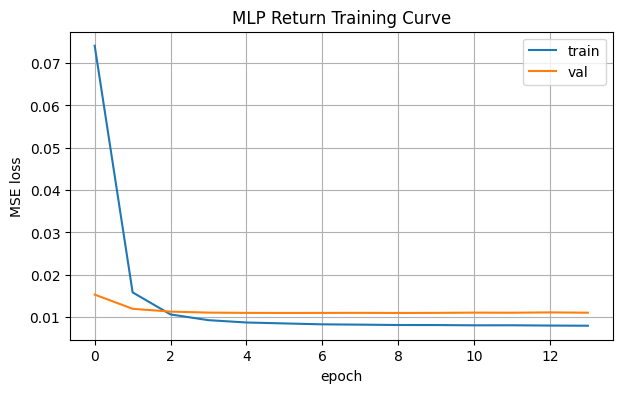

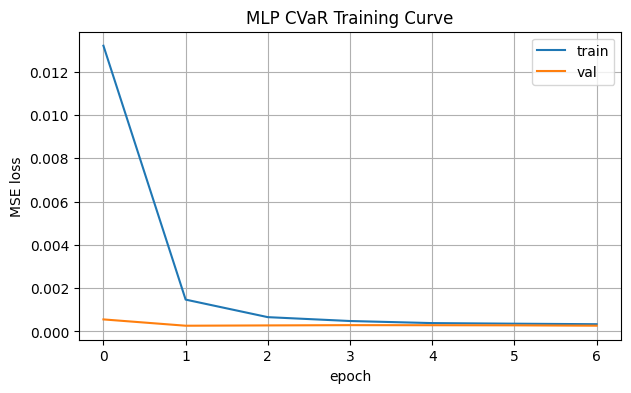

In [10]:
import matplotlib.pyplot as plt

def plot_history(hist, title):
    plt.figure(figsize=(7,4))
    plt.plot(hist.history["loss"], label="train")
    plt.plot(hist.history["val_loss"], label="val")
    plt.title(title)
    plt.xlabel("epoch")
    plt.ylabel("MSE loss")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history(hist_ret, "MLP Return Training Curve")
plot_history(hist_risk, "MLP CVaR Training Curve")
